### Análise de Risco de Crédito

#### 1.Introdução e Contexto de Negócio

A análise de risco de crédito é uma atividade central no setor financeiro, pois busca estimar a probabilidade de um cliente se tornar inadimplente. Decisões de concessão de crédito impactam diretamente a rentabilidade, a exposição ao risco e a sustentabilidade das instituições.

Neste notebook, desenvolvemos uma análise completa de risco de crédito, partindo da exploração dos dados até a construção de um modelo preditivo baseado em Regressão Logística, utilizando boas práticas de Ciência de Dados e Machine Learning.
O foco não está apenas na performance do modelo, mas também em interpretabilidade, clareza do pipeline e conexão com o problema de negócio.


In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
roc_auc_score,
roc_curve,
confusion_matrix,
classification_report
)

sns.set_style("whitegrid")

#### Carregamento e Inspeção Inicial dos Dados:

O primeiro passo prático consiste no carregamento do dataset e na inspeção inicial de sua estrutura. O objetivo é compreender:

- Quantidade de registros e variáveis 
- Tipos de dados
- Possíveis valores ausentes

In [ ]:
df = pd.read_excel('credit_risk_logistic_regression_dataset.xlsx')

df.head()

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     80000 non-null  float64
 1   gender                  80000 non-null  str    
 2   dependents              80000 non-null  int64  
 3   monthly_income          80000 non-null  float64
 4   employment_time_months  80000 non-null  float64
 5   credit_score            71855 non-null  float64
 6   credit_utilization      80000 non-null  float64
 7   open_credit_lines       80000 non-null  int64  
 8   previous_defaults       80000 non-null  int64  
 9   loan_amount             80000 non-null  float64
 10  loan_term_months        80000 non-null  int64  
 11  default_90d             80000 non-null  int64  
dtypes: float64(6), int64(5), str(1)
memory usage: 7.3 MB


,age,dependents,monthly_income,employment_time_months,credit_score,credit_utilization,open_credit_lines,previous_defaults,loan_amount,loan_term_months,default_90d
count,80000.000000,80000.000000,80000.000000,80000.000000,71855.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,40.101811,1.400287,5501.239257,74.789408,615.140252,0.298106,4.803312,0.408250,13784.489839,24.047400,0.200000
std,10.770176,1.181567,4189.107736,79.389067,85.035738,0.206735,2.196841,0.727642,11862.958571,14.282909,0.400003
min,18.000000,0.000000,217.868920,0.000858,300.000000,0.002403,0.000000,0.000000,549.185597,6.000000,0.000000
25%,32.575581,1.000000,2757.130124,19.849761,557.387349,0.150185,3.000000,0.000000,6278.599618,12.000000,0.000000
50%,40.019252,1.000000,4375.444532,48.986322,615.499807,0.241568,5.000000,0.000000,10446.582596,24.000000,0.000000
75%,47.450453,2.000000,6941.933107,102.264275,672.578140,0.384391,6.000000,1.000000,17255.007220,36.000000,0.000000
max,75.000000,6.000000,70738.497723,719.716680,850.000000,1.000000,18.000000,6.000000,221923.019773,48.000000,1.000000


#### Análise Exploratória de Dados (EDA)

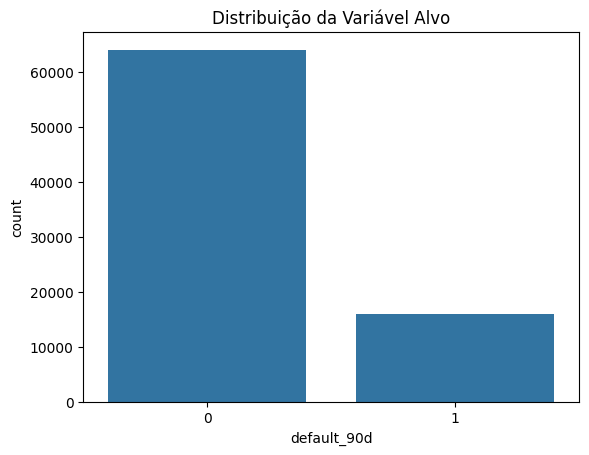

In [5]:
sns.countplot(x='default_90d', data=df)
plt.title('Distribuição da Variável Alvo')
plt.show()

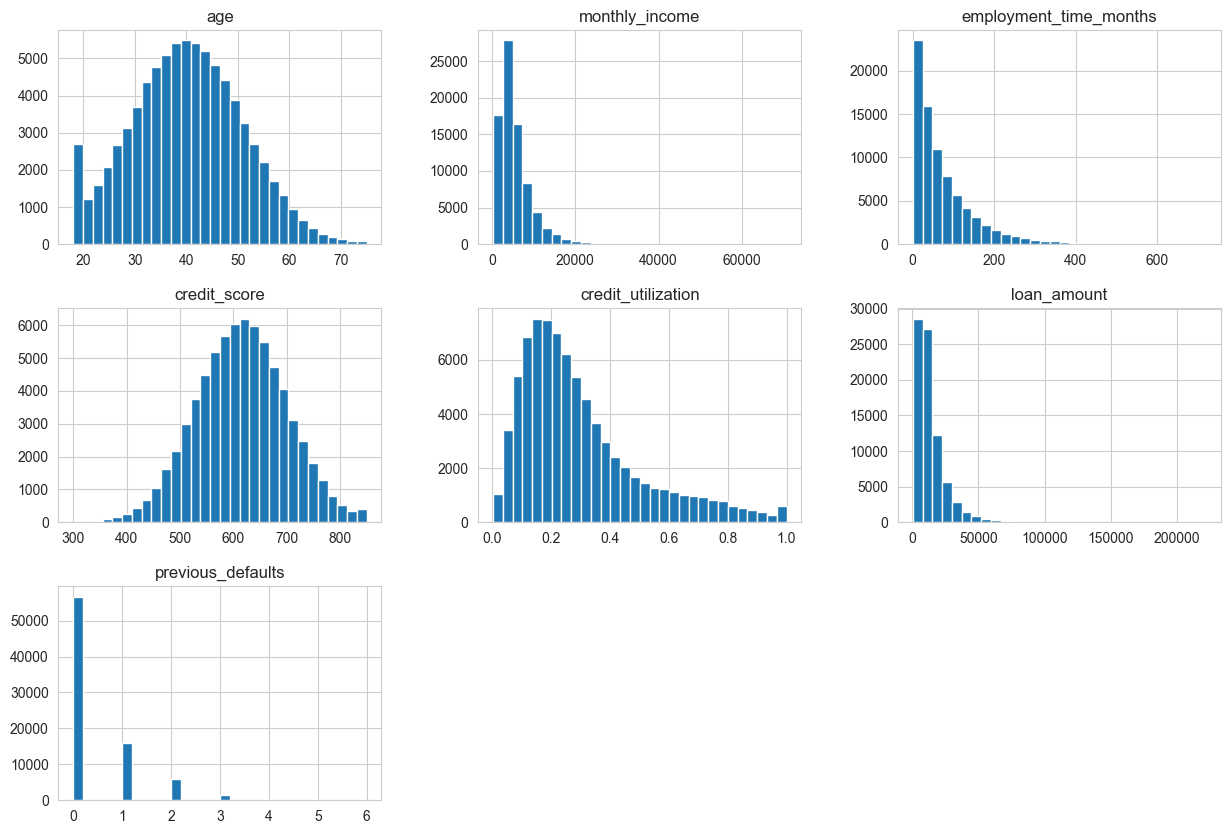

In [13]:
num_cols = [
    "age", "monthly_income", "employment_time_months",
    "credit_score", "credit_utilization",
    "loan_amount", "previous_defaults"
]

df[num_cols].hist(bins=30, figsize=(15, 10))
plt.show()

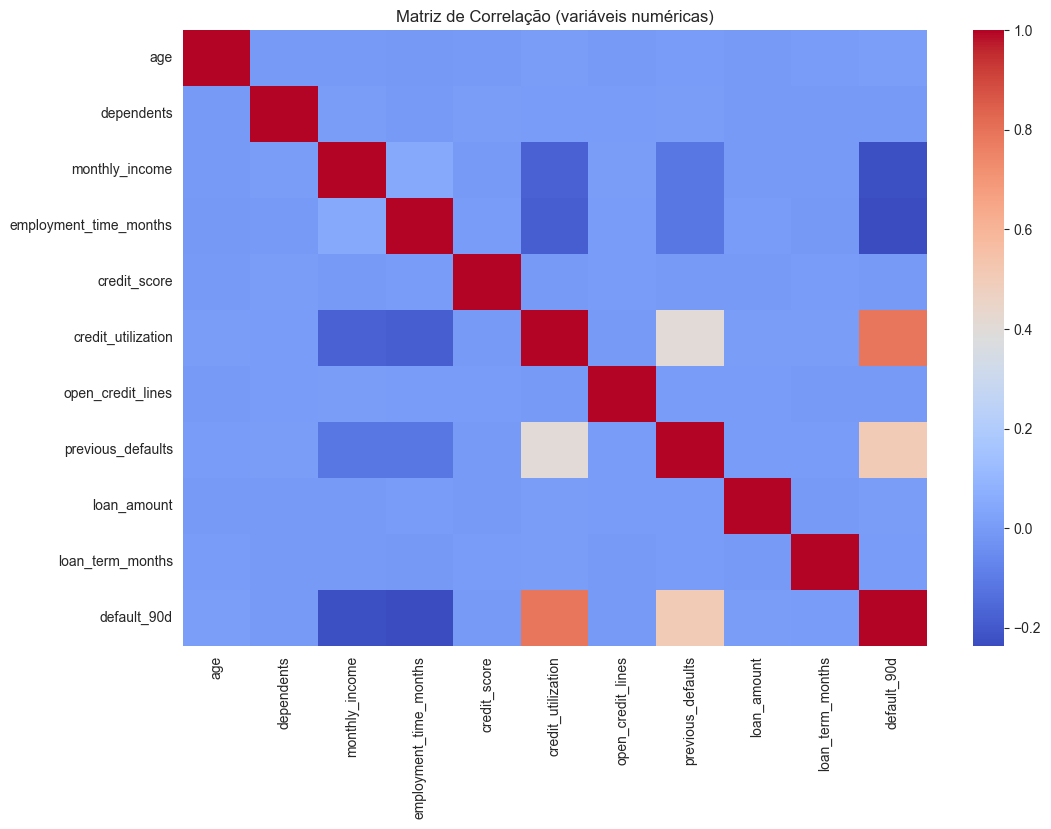

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=False,
            cmap='coolwarm')
plt.title('Matriz de Correlação (variáveis numéricas)')
plt.show()

####  Trás a observabilidade de que não temos nenhuma feature que tem uma forte correlação com as demais, isso garante que não vamos ter coeficiente instaveis e que a interpretabilidade vai ficar mais precisa.

In [17]:
X = df.drop('default_90d', axis=1)
y = df['default_90d']

categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(exclude=['object']).columns

/var/folders/z6/d9905jwj0qb77yl4mg5__75m0000gn/T/ipykernel_66433/2737951306.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns


In [18]:
numeric_transformer = Pipeline(steps=[
('imputer', SimpleImputer(strategy='median')),
('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
('imputer', SimpleImputer(strategy='most_frequent')),
('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessing = ColumnTransformer(
transformers=[
('num', numeric_transformer, numerical_features),
('cat', categorical_transformer, categorical_features)
]
)

#### Treinamento do modelo

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42, stratify=y
)

In [20]:
model = Pipeline(steps=[
('preprocessing', preprocessing),
('model', LogisticRegression(max_iter=1000))
])

In [27]:
param_grid = {
'model__C': [0.01, 0.1, 1, 10],
'model__l1_ratio': [0],
'model__solver': ['lbfgs']
}

grid = GridSearchCV(
model,
param_grid,
scoring='roc_auc',
cv=5,
n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__l1_ratio': [0], 'model__solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the s

In [28]:
best_model = grid.best_estimator_

In [29]:
y_pred_proba = best_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
roc_auc

0.9906224500868055

#### Parando para refletir aqui 

AUC tão alto assim indica que pode ter ocorrido algum erro no processo de treinamento ou estou trabalhando com dados que não corespondem com o a realidade tendo em vista que em situação de analise de credito um otimo AUC é de 0.9, e o meu está dando 0.99.


In [36]:
roc_auc_train = roc_auc_score(y_train, best_model.predict_proba(X_train)[:,1])
roc_auc_test  = roc_auc_score(y_test,  best_model.predict_proba(X_test)[:,1])

print(f"ROC AUC Train: {roc_auc_train:.4f}")
print(f"ROC AUC Test:  {roc_auc_test:.4f}") 

ROC AUC Train: 0.9911
ROC AUC Test:  0.9906


In [ ]:
#Estou sanity check para validar que não estou tendo training leakage.

y_random = np.random.permutation(y_train)
roc_auc_score(y_random, best_model.predict_proba(X_train)[:,1])

0.4999168207908163

#### Nesse momento percebo que nao tivemos um LEAKAGE, isso já é um alivio mas agora preciso entender o que está acontecendo para termos um resultado tão "perfeito".

### Conclusão


Dataset usado para esse processo possue um conjunto de dados com pouco ruido, os targets podem ter sido classificado de forma simples o que gera um dataset facil de se analisar, tendo em vista isso, o modelo não necessariamente está bom realmente, mas somente está trabalhando com dados de baixa complexidade.

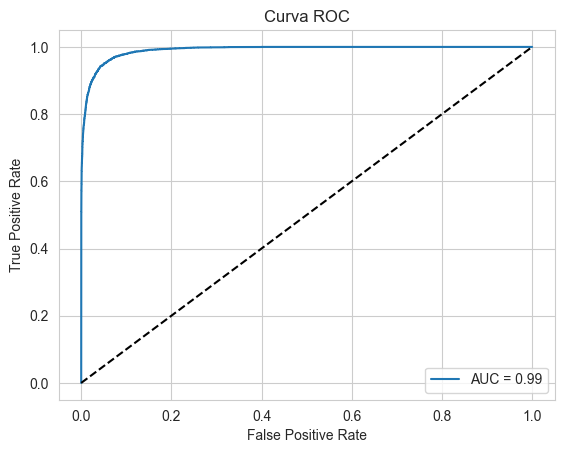

In [30]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('Curva ROC')
plt.show()

In [31]:
y_pred = best_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[18823   377]
 [  556  4244]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     19200
           1       0.92      0.88      0.90      4800

    accuracy                           0.96     24000
   macro avg       0.94      0.93      0.94     24000
weighted avg       0.96      0.96      0.96     24000



In [32]:
feature_names = (
list(numerical_features) +
list(best_model.named_steps['preprocessing']
.named_transformers_['cat']
.named_steps['encoder']
.get_feature_names_out(categorical_features))
)

coefficients = best_model.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
'feature': feature_names,
'coefficient': coefficients
}).sort_values(by='coefficient', ascending=False)

coef_df.head(10)

,feature,coefficient
5,credit_utilization,4.209661
7,previous_defaults,1.097938
0,age,0.054257
8,loan_amount,0.020405
10,gender_F,0.016362
11,gender_M,0.010622
6,open_credit_lines,0.008376
1,dependents,0.000216
9,loan_term_months,0.000123
4,credit_score,-0.025306


# Conclusão final

Realizei um processo consistente de analise e tratamento dos dados para buscar o melhor resultado possivel do modelo, contudo será necessario testar e valida esse processo com um dataset mais robusto que tenham mais ruido e represente de forma mais acertiva o que seria uma amostra de dados consistente com a problematica 